## Topic: End-to-End Machine Learning Project (Pipeline + Workflow)
### Learning Objectives

By the end of today, you will:

- Build a complete ML project from scratch
- Understand real-world workflow
- Use pipelines
- Prepare a GitHub-ready project

### Step 0 — Upload Dataset in Colab

Run this first cell to upload churn.csv

In [28]:
from google.colab import files
uploaded = files.upload()

Saving churn.csv to churn.csv


After upload → your file will be available.

### Step 1 — Import Libraries

In [29]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# ML tools
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

import joblib

### Step 2 — Load Dataset

In [30]:
# Load dataset
df = pd.read_csv("churn.csv")

# Show first rows
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,InternetService,SupportCalls,PaymentMethod,churn
0,C001,25,Male,2,2000,Monthly,Fiber,3,CreditCard,Yes
1,C002,45,Female,24,3500,Yearly,DSL,0,BankTransfer,No
2,C003,30,Male,6,2800,Monthly,Fiber,2,Easypaisa,Yes
3,C004,50,Female,36,4000,TwoYear,DSL,0,CreditCard,No
4,C005,22,Male,1,1800,Monthly,Fiber,4,Cash,Yes


In [31]:
# Load dataset
df = pd.read_csv("churn.csv")

# Show first rows
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,InternetService,SupportCalls,PaymentMethod,churn
0,C001,25,Male,2,2000,Monthly,Fiber,3,CreditCard,Yes
1,C002,45,Female,24,3500,Yearly,DSL,0,BankTransfer,No
2,C003,30,Male,6,2800,Monthly,Fiber,2,Easypaisa,Yes
3,C004,50,Female,36,4000,TwoYear,DSL,0,CreditCard,No
4,C005,22,Male,1,1800,Monthly,Fiber,4,Cash,Yes


In [32]:
# Basic info about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   CustomerID       20 non-null     object
 1   Age              20 non-null     int64 
 2   Gender           20 non-null     object
 3   Tenure           20 non-null     int64 
 4   MonthlyCharges   20 non-null     int64 
 5   Contract         20 non-null     object
 6   InternetService  20 non-null     object
 7   SupportCalls     20 non-null     int64 
 8   PaymentMethod    20 non-null     object
 9   churn            20 non-null     object
dtypes: int64(4), object(6)
memory usage: 1.7+ KB


In [33]:
# Check missing values
df.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
Tenure,0
MonthlyCharges,0
Contract,0
InternetService,0
SupportCalls,0
PaymentMethod,0
churn,0


### Step 3 — Data Cleaning

Real datasets are messy 👇

In [34]:
# Remove missing values
df.dropna(inplace=True)

# Remove duplicate rows
df.drop_duplicates(inplace=True)

print("New shape:", df.shape)

New shape: (20, 10)


### Step 4 — Exploratory Data Analysis (EDA)
#### 1: Target Distribution

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'MonthlyCharges', 'Contract',
       'InternetService', 'SupportCalls', 'PaymentMethod', 'churn'],
      dtype='object')


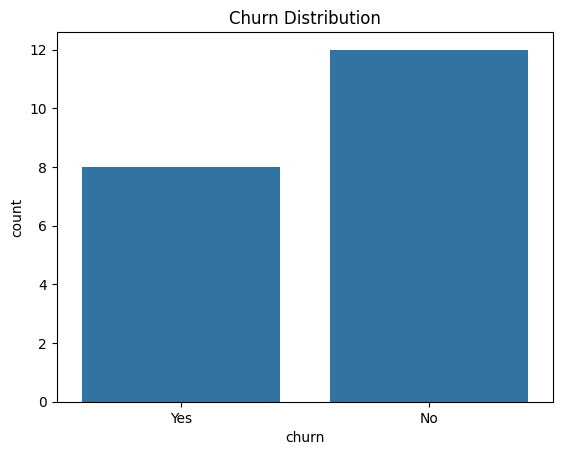

In [35]:
# Check column names
print(df.columns)

# Use the exact column name from the dataset
sns.countplot(x="churn", data=df)  # Replace "Churn" with the actual name
plt.title("Churn Distribution")
plt.show()

### 2: Correlation Heatmap (see relationships)

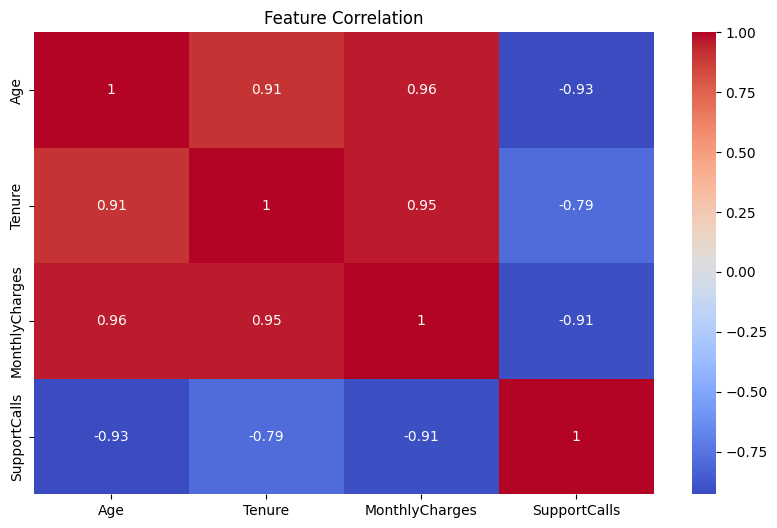

In [36]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

### Step 5 — Feature Engineering

Convert text → numbers.

In [37]:
# Convert categorical columns into numbers
df = pd.get_dummies(df, drop_first=True)

df.head()

,Age,Tenure,MonthlyCharges,SupportCalls,CustomerID_C002,CustomerID_C003,CustomerID_C004,CustomerID_C005,CustomerID_C006,CustomerID_C007,...,CustomerID_C019,CustomerID_C020,Gender_Male,Contract_TwoYear,Contract_Yearly,InternetService_Fiber,PaymentMethod_Cash,PaymentMethod_CreditCard,PaymentMethod_Easypaisa,churn_Yes
0,25,2,2000,3,False,False,False,False,False,False,...,False,False,True,False,False,True,False,True,False,True
1,45,24,3500,0,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
2,30,6,2800,2,False,True,False,False,False,False,...,False,False,True,False,False,True,False,False,True,True
3,50,36,4000,0,False,False,True,False,False,False,...,False,False,False,True,False,False,False,True,False,False
4,22,1,1800,4,False,False,False,True,False,False,...,False,False,True,False,False,True,True,False,False,True


###  Step 6 — Split Data

In [40]:
# Print all column names with quotes to reveal hidden spaces
print([col for col in df.columns])

['Age', 'Tenure', 'MonthlyCharges', 'SupportCalls', 'CustomerID_C002', 'CustomerID_C003', 'CustomerID_C004', 'CustomerID_C005', 'CustomerID_C006', 'CustomerID_C007', 'CustomerID_C008', 'CustomerID_C009', 'CustomerID_C010', 'CustomerID_C011', 'CustomerID_C012', 'CustomerID_C013', 'CustomerID_C014', 'CustomerID_C015', 'CustomerID_C016', 'CustomerID_C017', 'CustomerID_C018', 'CustomerID_C019', 'CustomerID_C020', 'Gender_Male', 'Contract_TwoYear', 'Contract_Yearly', 'InternetService_Fiber', 'PaymentMethod_Cash', 'PaymentMethod_CreditCard', 'PaymentMethod_Easypaisa', 'churn_Yes']


In [41]:
# Strip spaces from all column names
df.columns = df.columns.str.strip()

In [47]:
# Separate features and target
# Drop the target column "churn_Yes" from features
X = df.drop("churn_Yes", axis=1)

# Target column is "churn_Yes"
y = df["churn_Yes"]

# Split into train and test sets (80% train, 20% test)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Show shapes of training and testing sets
print("Train shape:", X_train.shape)   # rows, features for training
print("Test shape:", X_test.shape)     # rows, features for testing

Train shape: (16, 30)
Test shape: (4, 30)


### Step 7 — Build ML Pipeline (VERY IMPORTANT)

Pipeline = preprocessing + model together.

In [48]:
pipeline = Pipeline([
    # Step 1: Scale features
    ("scaler", StandardScaler()),

    # Step 2: Train model
    ("model", LogisticRegression(max_iter=1000))
])

### Step 8 — Train Model

In [49]:
# Train pipeline
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000))])

### Step 9 — Make Predictions

In [50]:
# Predict on test data
y_pred = pipeline.predict(X_test)

### Step 10 — Evaluate Model

In [51]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

       False       1.00      1.00      1.00         2
        True       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



You now have your baseline churn model

### Step 11 — Hyperparameter Tuning (Improve Model)

We tune Logistic Regression.

In [52]:
param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l2"]
}

In [53]:
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model',
                                        LogisticRegression(max_iter=1000))]),
             param_grid={'model__C': [0.01, 0.1, 1, 10],
                         'model__penalty': ['l2']},
             scoring='accuracy')

In [54]:
print("Best Parameters:", grid.best_params_)

Best Parameters: {'model__C': 0.1, 'model__penalty': 'l2'}


### Step 12 — Evaluate Tuned Model

In [55]:
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)

print("Tuned Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_best))

Tuned Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

       False       1.00      1.00      1.00         2
        True       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



 just improved the model like a real ML engineer

### Step 13 — Save Model

In [56]:
joblib.dump(best_model, "churn_model.pkl")
print("Model saved successfully!")

Model saved successfully!


In [57]:
# To download from Colab:
files.download("churn_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Step 14 — GitHub Project Structure

Create this structure on your PC:
```
ML-Churn-Project/
│
├── data/
│   └── churn.csv
│
├── notebook/
│   └── churn_analysis.ipynb
│
├── model/
│   └── churn_model.pkl
│
├── app/
│   └── app.py   (Flask later)
│
└── README.md
```


### What You Just Learned (Real Workflow)

You completed the full ML lifecycle:

1. Data loading
2. Cleaning
3. EDA
4. Feature engineering
5. Pipeline
6. Training
7. Evaluation
8. Hyperparameter tuning
9. Model saving

This is exactly what companies expect

### How to create app.py inside Google Colab

In Colab we create files using %%writefile

This command tells Colab:

👉 “Create a file and write code inside it”

### Step 1 — Open a NEW cell in Colab

Paste this FULL cell and run it.

In [59]:
%%writefile app.py
# ================================
# Customer Churn Prediction App
# ================================

from flask import Flask, request, render_template
import joblib
import numpy as np

app = Flask(__name__)

# Load trained model
model = joblib.load("churn_model.pkl")

@app.route('/')
def home():
    return "Churn Prediction App Running!"

@app.route('/predict', methods=['POST'])
def predict():
    features = request.json["features"]
    input_data = np.array([features])

    prediction = model.predict(input_data)[0]

    return {"prediction": int(prediction)}

if __name__ == "__main__":
    app.run()

Writing app.py


👉 This means file created successfully.

### Step 2 — Confirm file exists

Run this cell:

In [60]:
!ls

app.py	churn.csv  churn_model.pkl  sample_data


Now your Colab notebook has a real Python file

### Step 3 — Download app.py to your computer

Run this:

In [61]:
from google.colab import files
files.download("app.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Why we don’t run Flask in Colab?

Colab cannot host websites permanently.

Colab is only used to:
-  Train model
-  Save model
-  Create files
- Download files

Deployment happens on:
-  Render
-  Railway
- Local machine

### Colab Workflow Summary

In Colab you:

1. Train model
2. Save model → churn_model.pkl
3. Create app.py using %%writefile
4. Download files
5. Deploy outside Colab